## 1. Setup & Imports

Import libraries and configure the project root path to access `src/` modules.

In [2]:
import sys
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import re

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


## 2. Load Raw Data

Load the raw `CEAS_08` CSV from the raw data directory and inspect its shape.

In [3]:
from src.config import RAW_DATA_DIR

db = pd.read_csv(RAW_DATA_DIR / "CEAS_08.csv")
db.shape


(39154, 7)

In [4]:
db.head(2)


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1


In [5]:
db.isnull().sum()


sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

In [6]:
db.info()


<class 'pandas.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    39154 non-null  str  
 1   receiver  38692 non-null  str  
 2   date      39154 non-null  str  
 3   subject   39126 non-null  str  
 4   body      39154 non-null  str  
 5   label     39154 non-null  int64
 6   urls      39154 non-null  int64
dtypes: int64(2), str(5)
memory usage: 2.1 MB


In [7]:
# check for empty string cells
for col in db.columns:
    empty = (db[col].astype(str).str.strip() == "").sum()
    if empty > 0:
        print(f"{col}: {empty} empty strings")


In [8]:
# combine subject + body into text, fill empty subject
db["subject"] = db["subject"].fillna("").astype(str).str.strip()
db["body"] = db["body"].fillna("").astype(str)
db["text"] = db["subject"] + " " + db["body"]
db["text"] = db["text"].str.strip()

print(f"Text samples after combine: {len(db)}")
print(f"Empty text count: {(db['text'] == '').sum()}")


Text samples after combine: 39154
Empty text count: 0


In [9]:
# keep only label and text for now; urls column is binary, will recompute
db.drop(columns=["sender", "receiver", "date", "subject", "body", "urls"], inplace=True)
db.columns.tolist()


['label', 'text']

## 3. Feature Engineering

Extract numeric features from the raw text: URL count, exclamation/question marks, dollar signs, ALL-CAPS words, numbers, word count, and capitalisation ratio.

In [10]:
db["num_urls"]        = db["text"].str.findall(r'https?://\S+|www\.\S+').str.len()
db["num_exclamation"] = db["text"].str.count(r'!')
db["num_question"]    = db["text"].str.count(r'\?')
db["num_dollar"]      = db["text"].str.count(r'\$')
db["num_all_caps"]    = db["text"].str.findall(r'\b[A-Z]{2,}\b').str.len()
db["num_numbers"]     = db["text"].str.findall(r'\d+').str.len()
db["word_count"]      = db["text"].str.split().str.len()
caps   = db["text"].str.findall(r'[A-Z]').str.len()
letters = db["text"].str.findall(r'[A-Za-z]').str.len()
db["capital_ratio"]   = np.where(letters > 0, caps / letters, 0)


## 4. Emoji Count Feature

Count the number of emoji characters in each email text.

In [11]:
import emoji

db["emoji_count"] = db["text"].apply(emoji.emoji_count)


## 5. Exploratory Data Analysis

Visualise the class distribution with a pie chart and compare average feature values between spam and ham emails.

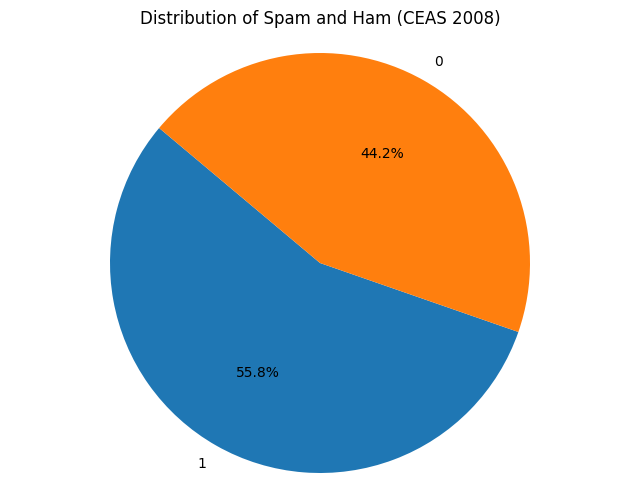

In [12]:
db['label'].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.pie(db['label'].value_counts(), labels=db['label'].value_counts().index,
        autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Spam and Ham (CEAS 2008)')
plt.axis('equal')
plt.show()


In [13]:
db.groupby("label")["emoji_count"].mean()


label
0    0.051698
1    0.064555
Name: emoji_count, dtype: float64

In [14]:
db.groupby('label')['num_exclamation'].mean()


label
0    1.111483
1    0.908754
Name: num_exclamation, dtype: float64

In [15]:
db.groupby('label')['num_dollar'].mean()


label
0    1.222043
1    0.098617
Name: num_dollar, dtype: float64

In [16]:
db.groupby('label')['num_question'].mean()


label
0    2.551409
1    1.995147
Name: num_question, dtype: float64

In [17]:
db.groupby('label')['num_all_caps'].mean()


label
0    13.268658
1    17.080350
Name: num_all_caps, dtype: float64

In [18]:
db.groupby('label')['capital_ratio'].mean()


label
0    0.077036
1    0.100880
Name: capital_ratio, dtype: float64

In [19]:
db.groupby('label')['num_numbers'].mean()


label
0    41.976375
1    16.322590
Name: num_numbers, dtype: float64

In [20]:
db.groupby('label')['num_urls'].mean()


label
0    2.899723
1    3.794616
Name: num_urls, dtype: float64

In [21]:
db.groupby('label')['word_count'].mean()


label
0    358.224931
1     89.079892
Name: word_count, dtype: float64

In [22]:
db.info()


<class 'pandas.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   label            39154 non-null  int64  
 1   text             39154 non-null  str    
 2   num_urls         39154 non-null  int64  
 3   num_exclamation  39154 non-null  int64  
 4   num_question     39154 non-null  int64  
 5   num_dollar       39154 non-null  int64  
 6   num_all_caps     39154 non-null  int64  
 7   num_numbers      39154 non-null  int64  
 8   word_count       39154 non-null  int64  
 9   capital_ratio    39154 non-null  float64
 10  emoji_count      39154 non-null  int64  
dtypes: float64(1), int64(9), str(1)
memory usage: 3.3 MB


## 6. Deduplication

Remove duplicate rows based on the `text` column to avoid data leakage.

In [23]:
db.drop_duplicates(subset="text", inplace=True)
db.shape


(39145, 11)

## 7. Text Cleaning

Import the `clean_db_text` function for heavy-duty text cleaning (bracket/hex removal, normalisation).

In [ ]:
from src.preprocess import clean_db_text


Apply `clean_db_text` to every row and re-deduplicate after cleaning.

In [25]:
db["text"] = db["text"].apply(clean_db_text)
db.drop_duplicates(subset="text", inplace=True)
print(f"After cleaning: {db.shape}")


After cleaning: (33066, 11)


In [26]:
db["text"].iloc[0]


'never agree to be a loser buck up your troubles caused by small dimension will soon be over! become a lover no woman will be able to resist! [url] come even as nazi tanks were rolling down the streets the dreamersphilosopher or a journalist he was still not surei do the same'

In [27]:
db["text"] = db["text"].str.replace("_", "", regex=False)


## 8. Advanced Text Processing 

Apply stopword removal and stemming via `process_text_advanced`. (Cell may be left unexecuted.)

In [ ]:
from src.preprocess import process_text_advanced
db["text"] = db["text"].apply(process_text_advanced)


In [30]:
db["text"].iloc[0]


'never agre loser buck troubl caus small dimens soon over! becom lover woman abl resist! [url] come even nazi tank roll street dreamersphilosoph journalist still surei'

In [31]:
db.shape


(33066, 11)

In [32]:
db["label"].value_counts()


label
0    17134
1    15932
Name: count, dtype: int64

## 9. Regex Cleanup

Remove noise tokens: underscores, repeated `-+=` characters, and angle brackets/slashes.

In [38]:
# remove - + = from the text
db["text"] = db["text"].str.replace(r'[-+=]{2,}', ' ', regex=True)

# remove > <
db["text"] = db["text"].str.replace(r'[<>/]', '', regex=True)


## 10. Save Cleaned Dataset

Write the cleaned and feature-engineered dataset to the processed data directory.

In [39]:
from src.config import PROCESSED_DATA_DIR
db.to_csv(PROCESSED_DATA_DIR / "cleaned_ceas_08.csv", index=False)
print(f"Saved to {PROCESSED_DATA_DIR / 'cleaned_ceas_08.csv'}")


Saved to C:\Users\aungm\university\computing\cos30049-email-spam-detection\data\processed\cleaned_ceas_08.csv
